In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import wfdb
import random

# =============================
# PARAMETERS
# =============================
selected_patients = ['215', '213', '209', '203', '210', '116', '222', '233', 
                     '118', '223', '221', '214', '200', '228', '201', '208', 
                     '119', '207', '106']

input_lengths = [10, 20, 30, 40, 50]
pca_dims = [2, 3, 4]

data_folder = 'mitdb_data_full'
annotation_folder = 'mit-bih-arrhythmia-database-1.0.0'
NORMAL_BEATS = ['.', 'N', 'L', 'R', 'e', 'j']
beat_length = 180

num_train_beats = 500
num_val_beats = 100

# =============================
# FUNCTIONS
# =============================
def get_segments(signal, ann_samples, ann_symbols, beat_length, target_symbols):
    segments = []
    for s, sym in zip(ann_samples, ann_symbols):
        if sym in target_symbols and s >= beat_length:
            seg = signal[s - beat_length:s]
            segments.append(seg)
    return segments

def sliding_data(segment, input_len):
    X_y = []
    for t_idx in range(len(segment) - input_len + 1):
        X_y.append(segment[t_idx : t_idx + input_len])
    return np.array(X_y).T

# =============================
# MAIN LOOP
# =============================
num_cols = len(pca_dims) * len(input_lengths)
total_var_matrix = np.zeros((len(selected_patients), num_cols))

for p_idx, record in enumerate(selected_patients):
    print(f"Processing patient {record}...")

    # Load signal and annotation
    ann = wfdb.rdann(os.path.join(annotation_folder, record), extension='atr')
    signal_path = os.path.join(data_folder, f'{record}.npy')
    signal = np.load(signal_path)[:, 0]  # Lead I only

    # Extract normal beats
    normal_segments = get_segments(signal, ann.sample, ann.symbol, beat_length, NORMAL_BEATS)
    if len(normal_segments) == 0:
        print(f"No normal beats for patient {record}, skipping.")
        continue

    # Split into train, val, test (same as your code)
    all_norm_indices = np.arange(len(normal_segments))
    np.random.shuffle(all_norm_indices)

    val_indices = all_norm_indices[:num_val_beats]
    train_indices = all_norm_indices[num_val_beats:num_val_beats + num_train_beats]

    train_segments = [normal_segments[i] for i in train_indices]

    # Loop over PCA dims and input lengths
    col_idx = 0
    for d in pca_dims:
        for input_len in input_lengths:
            all_X_y_raw = []
            for seg in train_segments:
                if len(seg) < input_len:
                    continue
                X_y_raw = sliding_data(seg, input_len)
                if X_y_raw.size == 0:
                    continue
                all_X_y_raw.append(X_y_raw)

            if len(all_X_y_raw) == 0:
                total_var_matrix[p_idx, col_idx] = np.nan
                col_idx += 1
                continue

            X_train = np.hstack(all_X_y_raw).T
            pca = PCA(n_components=d)
            pca.fit(X_train)
            total_var_matrix[p_idx, col_idx] = np.sum(pca.explained_variance_ratio_)
            col_idx += 1


Processing patient 215...
Processing patient 213...
Processing patient 209...
Processing patient 203...
Processing patient 210...
Processing patient 116...
Processing patient 222...
Processing patient 233...
Processing patient 118...
Processing patient 223...
Processing patient 221...
Processing patient 214...
Processing patient 200...
Processing patient 228...
Processing patient 201...
Processing patient 208...
Processing patient 119...
Processing patient 207...
Processing patient 106...


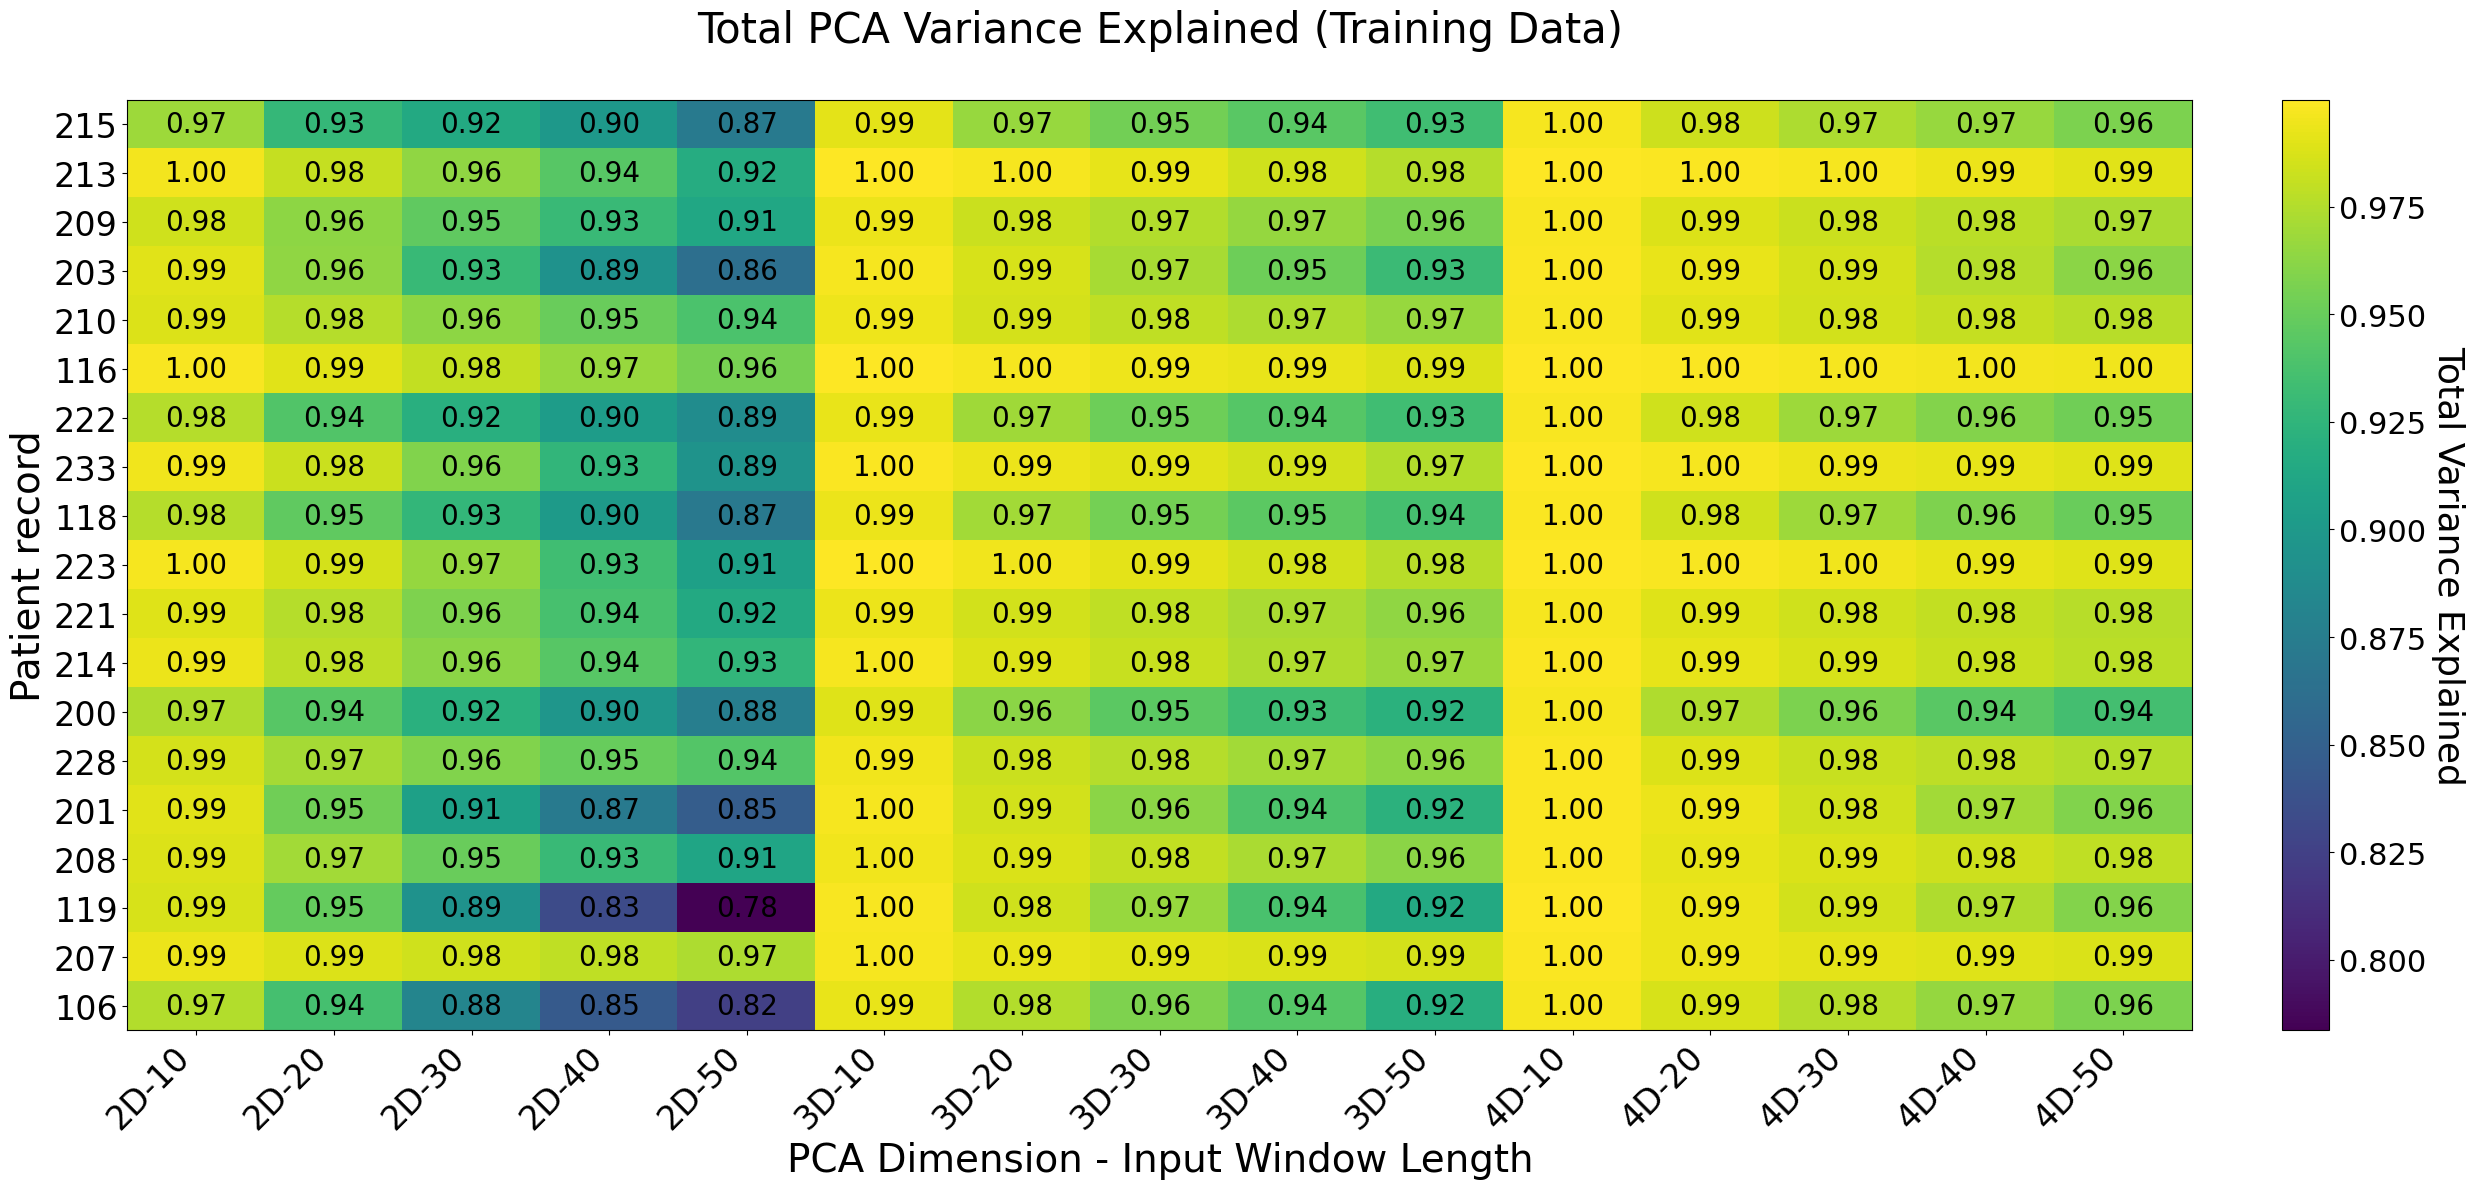

In [16]:
fig, ax = plt.subplots(figsize=(25, 12))  # bigger figure

im = ax.imshow(total_var_matrix, cmap='viridis', aspect='auto')

# Columns labels: PCA dim × input lengths
col_labels = [f"{d}D-{w}" for d in pca_dims for w in input_lengths]
ax.set_xticks(np.arange(num_cols))
ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=24)  # bigger font

ax.set_yticks(np.arange(len(selected_patients)))
ax.set_yticklabels(selected_patients, fontsize=24)  # bigger font

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=22)          # increase tick labels on colorbar
cbar.ax.set_ylabel("Total Variance Explained", rotation=-90, va="bottom", fontsize=26)

# Annotate values with larger font
for i in range(len(selected_patients)):
    for j in range(num_cols):
        ax.text(j, i, f"{total_var_matrix[i,j]:.2f}",
                ha="center", va="center", color="k", fontsize=20)

ax.set_title("Total PCA Variance Explained (Training Data)\n", fontsize=30)
ax.set_xlabel("PCA Dimension - Input Window Length", fontsize=28)
ax.set_ylabel("Patient record", fontsize=28)
plt.tight_layout()
# Save figure in 300 dpi
fig_path = "PCA_total_variance_heatmap.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()